# AI Card Classifier
find the dataset at: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import random

# Para mejorar la visualización en notebooks
%matplotlib inline

In [ ]:
DATA_DIR = 'dataset'

file_paths = []
original_labels = []
datasets = []

for root, dirs, files in os.walk(DATA_DIR):
    if not files:
        continue
    
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')): # asserts
            file_path = os.path.join(root, file)
            file_paths.append(file_path)
            
            # El nombre de la etiqueta es el nombre de la carpeta
            label = os.path.basename(root)
            original_labels.append(label)
            
            # El nombre del dataset (train/test/valid) es el padre de la carpeta de la etiqueta
            dataset_type = os.path.basename(os.path.dirname(root))
            datasets.append(dataset_type)

# Creamos el DataFrame
df = pd.DataFrame({
    'filepath': file_paths,
    'dataset': datasets,
    'label_original': original_labels
})

print(f"Total de imágenes encontradas: {len(df)}")
df.head()

Total de imágenes encontradas: 8154


,filepath,dataset,label_original
0,dataset\test\ace of clubs\1.jpg,test,ace of clubs
1,dataset\test\ace of clubs\2.jpg,test,ace of clubs
2,dataset\test\ace of clubs\3.jpg,test,ace of clubs
3,dataset\test\ace of clubs\4.jpg,test,ace of clubs
4,dataset\test\ace of clubs\5.jpg,test,ace of clubs


In [ ]:
def get_suit_class(label):
    label = label.lower()
    
    if 'hearts' in label or 'heart' in label:
        return 'corazones'
    elif 'diamonds' in label or 'diamond' in label:
        return 'diamantes'
    elif 'spades' in label or 'spade' in label:
        return 'picas'
    elif 'clubs' in label or 'club' in label:
        return 'treboles'
    else:
        return 'outlier'

df['palo'] = df['label_original'].apply(get_suit_class)

print("DataFrame con la nueva clase 'palo':")
df.head()

DataFrame con la nueva clase 'palo':


,filepath,dataset,label_original,palo
0,dataset\test\ace of clubs\1.jpg,test,ace of clubs,treboles
1,dataset\test\ace of clubs\2.jpg,test,ace of clubs,treboles
2,dataset\test\ace of clubs\3.jpg,test,ace of clubs,treboles
3,dataset\test\ace of clubs\4.jpg,test,ace of clubs,treboles
4,dataset\test\ace of clubs\5.jpg,test,ace of clubs,treboles


Distribución de imágenes por palo (Total):
palo
picas        2161
corazones    1975
diamantes    1957
treboles     1936
outlier       125
Name: count, dtype: int64

Distribución de imágenes por palo (Solo Entrenamiento):
palo
picas        2031
corazones    1845
diamantes    1827
treboles     1806
outlier       115
Name: count, dtype: int64


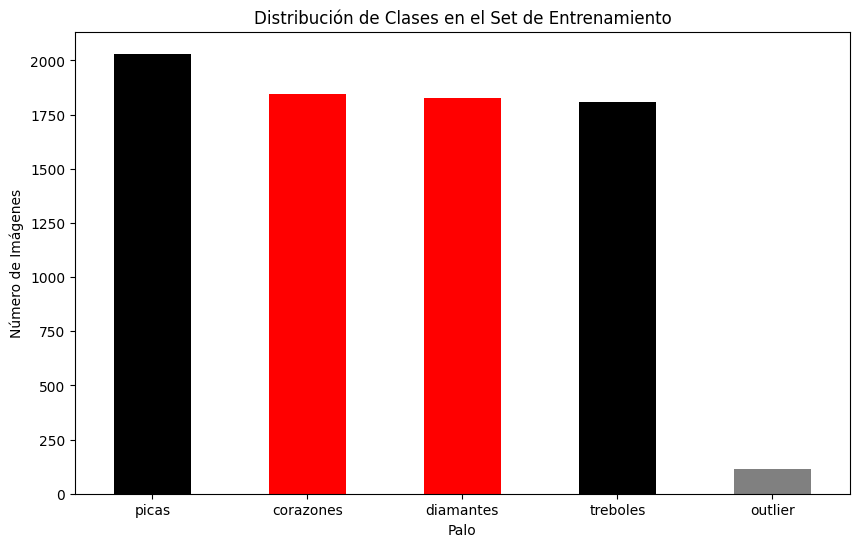

In [ ]:
# Estado de equilibrio del dataset
# Imágenes por palo
print("Distribución de imágenes por palo (Total):")
print(df['palo'].value_counts())

print("\nDistribución de imágenes por palo (Solo Entrenamiento):")
print(df[df['dataset'] == 'train']['palo'].value_counts())

plt.figure(figsize=(10, 6))
df[df['dataset'] == 'train']['palo'].value_counts().plot(kind='bar', color=['black', 'red', 'red', 'black', 'grey'])
plt.title('Distribución de Clases en el Set de Entrenamiento')
plt.xlabel('Palo')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=0)
plt.show()

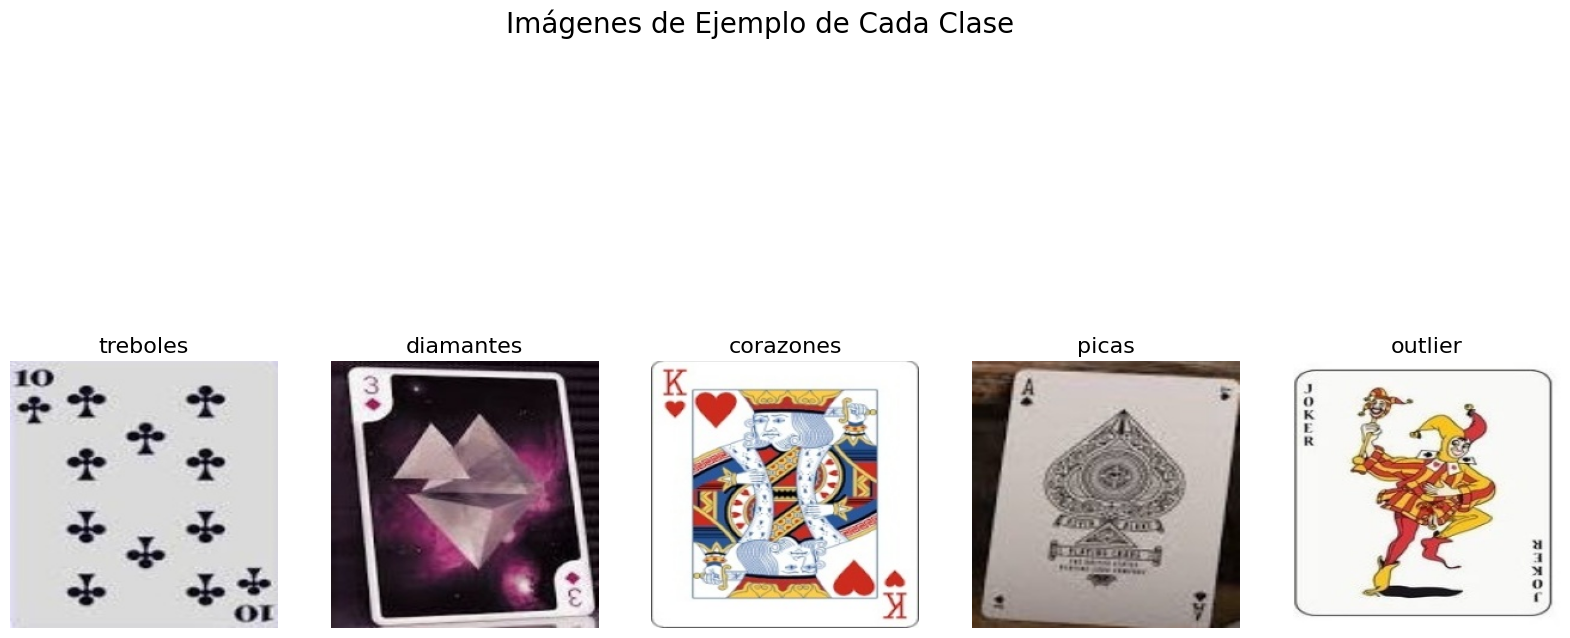

In [ ]:
clases = df['palo'].unique()

plt.figure(figsize=(20, 10))
plt.suptitle('Imágenes de Ejemplo de Cada Clase', fontsize=20)

for i, clase in enumerate(clases):
    # 1. Filtramos el DataFrame por la clase actual y el set de 'train'
    df_clase = df[(df['palo'] == clase) & (df['dataset'] == 'train')]
    
    # 2. Rruta de archivo aleatoria
    random_path = random.choice(df_clase['filepath'].values)
    
    # 3. Cargamos la imagen
    # Usamos cv2.imread y lo convertimos de BGR (OpenCV) a RGB (Matplotlib)
    img = cv2.imread(random_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 4. La mostramos
    ax = plt.subplot(1, len(clases), i + 1)
    ax.imshow(img)
    ax.set_title(clase, fontsize=16)
    ax.axis('off')

plt.show()